In [1]:
!pip install -U datasets pandas numpy scikit_learn pillow matplotlib

In [2]:
from datasets import load_dataset
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from collections import Counter

SEED = 42

In [3]:
ds = load_dataset("arunapb/nutrition5K-foodseg103")
print(ds)

README.md:   0%|          | 0.00/1.10k [00:00<?, ?B/s]

data/train-00000-of-00001.parquet: reconstructing file:   0%|          |  0.00B / 75.8MB            

data/train-00000-of-00001.parquet: downloading bytes:           |  0.00B            

data/test-00000-of-00001.parquet: reconstructing file:   0%|          |  0.00B / 8.25MB            

data/test-00000-of-00001.parquet: downloading bytes:           |  0.00B            

Generating train split: 0 examples [00:00, ? examples/s]

Generating test split: 0 examples [00:00, ? examples/s]

DatasetDict({
    train: Dataset({
        features: ['image', 'id', 'split', 'ingredients', 'fs103_classes', 'total_calories', 'total_mass', 'total_fat', 'total_carb', 'total_protein'],
        num_rows: 891
    })
    test: Dataset({
        features: ['image', 'id', 'split', 'ingredients', 'fs103_classes', 'total_calories', 'total_mass', 'total_fat', 'total_carb', 'total_protein'],
        num_rows: 100
    })
})


In [4]:
train_ds = ds["train"]
print("Number of samples:", len(train_ds))
print()
print("Features:")
print(train_ds.features)

Number of samples: 891

Features:
{'image': Image(mode=None, decode=True), 'id': Value('string'), 'split': Value('string'), 'ingredients': List({'calories': Value('float64'), 'carb': Value('float64'), 'fat': Value('float64'), 'grams': Value('float64'), 'id': Value('string'), 'name': Value('string'), 'protein': Value('float64')}), 'fs103_classes': List(Value('string')), 'total_calories': Value('float64'), 'total_mass': Value('float64'), 'total_fat': Value('float64'), 'total_carb': Value('float64'), 'total_protein': Value('float64')}


In [5]:
# ============================================================
# TEAM B - STEP 1
# Nutrition5K Class Coverage Audit
# ============================================================

from collections import Counter, defaultdict
import pandas as pd


# Exact 41 classes used by Team A / YOLO model
TEAM_A_CLASSES = [
    "rice",
    "sushi",
    "fried rice",
    "toast",
    "croissant",
    "hamburger",
    "pizza",
    "sandwiches",
    "ramen noodle",
    "spaghetti",
    "gratin",
    "miso soup",
    "sausage",
    "omelet",
    "grilled salmon",
    "fried chicken",
    "steak",
    "egg sunny-side up",
    "roast chicken",
    "potato salad",
    "green salad",
    "rice ball",
    "hot dog",
    "french fries",
    "pancake",
    "mushroom risotto",
    "chicken nugget",
    "scrambled egg",
    "lasagna",
    "brownie",
    "apple",
    "banana",
    "tomato",
    "lemon",
    "litchi",
    "mango",
    "orange",
    "peach",
    "pear",
    "plum",
    "kiwi"
]


# Collect all Nutrition5K fs103 classes
nutrition_class_counts = Counter()

for item in train_ds:
    for cls in item["fs103_classes"]:
        nutrition_class_counts[cls] += 1


nutrition_classes = sorted(
    nutrition_class_counts.keys()
)


print("Nutrition5K classes:", len(nutrition_classes))
print("Team A classes:", len(TEAM_A_CLASSES))

Nutrition5K classes: 42
Team A classes: 41


In [6]:
# ============================================================
# EXACT CLASS MATCH
# ============================================================

exact_matches = []
missing_classes = []

for cls in TEAM_A_CLASSES:

    if cls in nutrition_class_counts:

        exact_matches.append({
            "team_a_class": cls,
            "nutrition5k_class": cls,
            "count": nutrition_class_counts[cls]
        })

    else:
        missing_classes.append(cls)


coverage_df = pd.DataFrame(exact_matches)

print("\n--- EXACT MATCHES ---")
print(coverage_df.to_string(index=False))

print("\nExact matches:", len(exact_matches), "/", len(TEAM_A_CLASSES))

print("\n--- NO EXACT MATCH ---")

for cls in missing_classes:
    print("-", cls)


--- EXACT MATCHES ---
team_a_class nutrition5k_class  count
        rice              rice     18
       pizza             pizza     84
     sausage           sausage     51
       steak             steak      3
       apple             apple     81
      banana            banana      1
      tomato            tomato      5
      orange            orange     24
        pear              pear     28

Exact matches: 9 / 41

--- NO EXACT MATCH ---
- sushi
- fried rice
- toast
- croissant
- hamburger
- sandwiches
- ramen noodle
- spaghetti
- gratin
- miso soup
- omelet
- grilled salmon
- fried chicken
- egg sunny-side up
- roast chicken
- potato salad
- green salad
- rice ball
- hot dog
- french fries
- pancake
- mushroom risotto
- chicken nugget
- scrambled egg
- lasagna
- brownie
- lemon
- litchi
- mango
- peach
- plum
- kiwi


In [7]:
# ============================================================
# SEARCH POSSIBLE RELATED CLASSES
# ============================================================

from difflib import get_close_matches

print("\n--- POSSIBLE NUTRITION5K MATCHES ---")

for cls in missing_classes:

    matches = get_close_matches(
        cls,
        nutrition_classes,
        n=5,
        cutoff=0.25
    )

    print(f"\n{cls}:")

    if matches:
        for m in matches:
            print(
                f"   {m:<30} "
                f"count={nutrition_class_counts[m]}"
            )
    else:
        print("   No similar class name found")


--- POSSIBLE NUTRITION5K MATCHES ---

sushi:
   sausage                        count=51
   fish                           count=2
   asparagus                      count=4
   enoki mushroom                 count=11
   cauliflower                    count=77

fried rice:
   dried cranberries              count=55
   rice                           count=18
   bread                          count=2
   lettuce                        count=2
   pineapple                      count=44

toast:
   tomato                         count=5
   pasta                          count=3
   tofu                           count=8
   steak                          count=3
   potato                         count=74

croissant:
   carrot                         count=54
   corn                           count=50
   orange                         count=24
   olives                         count=44
   celery stick                   count=3

hamburger:
   sausage                        count=51
   cucumber    

In [8]:
# ============================================================
# DISH-LEVEL OCCURRENCE
# ============================================================

dish_occurrence = Counter()

for item in train_ds:

    unique_classes = set(
        item["fs103_classes"]
    )

    for cls in unique_classes:
        dish_occurrence[cls] += 1


print("--- TEAM A EXACT CLASS OCCURRENCE ---")

for cls in TEAM_A_CLASSES:

    if cls in dish_occurrence:

        print(
            f"{cls:<22} "
            f"{dish_occurrence[cls]:>5} dishes"
        )

--- TEAM A EXACT CLASS OCCURRENCE ---
rice                      18 dishes
pizza                     84 dishes
sausage                   51 dishes
steak                      3 dishes
apple                     81 dishes
banana                     1 dishes
tomato                     5 dishes
orange                    24 dishes
pear                      28 dishes


In [9]:
# ============================================================
# NUTRITION METADATA AUDIT
# ============================================================

valid_mass = 0
valid_calories = 0
valid_both = 0
invalid_examples = []

for item in train_ds:

    mass = item["total_mass"]
    calories = item["total_calories"]

    mass_ok = (
        mass is not None
        and float(mass) > 0
    )

    calorie_ok = (
        calories is not None
        and float(calories) > 0
    )

    if mass_ok:
        valid_mass += 1

    if calorie_ok:
        valid_calories += 1

    if mass_ok and calorie_ok:
        valid_both += 1

    elif len(invalid_examples) < 10:
        invalid_examples.append(
            (
                item["id"],
                mass,
                calories
            )
        )


print("Total dishes:", len(train_ds))
print("Valid mass:", valid_mass)
print("Valid calories:", valid_calories)
print("Valid both:", valid_both)

print("\nInvalid examples:")
for x in invalid_examples:
    print(x)

Total dishes: 891
Valid mass: 891
Valid calories: 855
Valid both: 855

Invalid examples:
('dish_1573849852', 182.0, 0.0)
('dish_1571931678', 351.0, 0.0)
('dish_1572538461', 167.0, 0.0)
('dish_1572376754', 60.0, 0.0)
('dish_1572453675', 38.0, 0.0)
('dish_1572365610', 167.0, 0.0)
('dish_1575923893', 115.0, 0.0)
('dish_1572540934', 357.0, 0.0)
('dish_1576171118', 53.0, 0.0)
('dish_1574357682', 68.0, 0.0)


In [10]:
# ============================================================
# TEAM B - STEP 2
# Build valid regression metadata
# ============================================================

import pandas as pd
import numpy as np


regression_data = []

for item in train_ds:

    mass = float(item["total_mass"])
    calories = float(item["total_calories"])

    if mass <= 0 or calories <= 0:
        continue

    kcal_per_gram = calories / mass

    regression_data.append({
        "dish_id": item["id"],
        "total_mass_g": mass,
        "total_calories": calories,
        "kcal_per_gram": kcal_per_gram,
        "ingredients": item["fs103_classes"]
    })


regression_df = pd.DataFrame(regression_data)

print("Valid dishes:", len(regression_df))

display(
    regression_df.head()
)

Valid dishes: 855


,dish_id,total_mass_g,total_calories,kcal_per_gram,ingredients
0,dish_1567629081,90.0,239.309998,2.65900,[pizza]
1,dish_1558378634,315.0,874.966003,2.77767,"[grape, almond, sausage]"
2,dish_1558381819,65.0,22.100000,0.34000,[tomato]
3,dish_1567801468,196.0,86.239998,0.44000,[salad]
4,dish_1562686492,100.0,160.000000,1.60000,[apple]


In [11]:
# ============================================================
# REGRESSION TARGET STATISTICS
# ============================================================

stats = regression_df[
    [
        "total_mass_g",
        "total_calories",
        "kcal_per_gram"
    ]
].describe()

display(stats)

,total_mass_g,total_calories,kcal_per_gram
count,855.000000,855.000000,855.000000
mean,133.095906,150.973301,1.343934
std,101.471943,162.726824,1.453243
min,6.000000,2.400000,0.100000
25%,62.500000,39.500000,0.440000
50%,105.000000,91.680000,0.690000
75%,162.500000,208.128997,1.600000
max,706.000000,1050.511108,5.781000


In [12]:
# ============================================================
# CHECK EXTREME VALUES
# ============================================================

print("Lowest kcal/g:")

display(
    regression_df
    .sort_values("kcal_per_gram")
    .head(10)
)


print("\nHighest kcal/g:")

display(
    regression_df
    .sort_values(
        "kcal_per_gram",
        ascending=False
    )
    .head(10)
)

Lowest kcal/g:


,dish_id,total_mass_g,total_calories,kcal_per_gram,ingredients
828,dish_1562008394,24.0,2.400000,0.100000,[cucumber]
297,dish_1562096343,62.0,6.200000,0.100000,[cucumber]
196,dish_1557863012,31.0,3.100000,0.100000,[cucumber]
809,dish_1568666184,190.0,28.500002,0.150000,[lettuce]
311,dish_1560455000,84.0,12.800001,0.152381,"[cherry, cucumber]"
342,dish_1556575124,28.0,4.480000,0.160000,[celery stick]
134,dish_1558460138,56.0,10.080000,0.180000,[cherry]
123,dish_1558636514,89.0,16.020000,0.180000,[cherry]
473,dish_1558639683,89.0,16.020000,0.180000,[cherry]
576,dish_1558639673,89.0,16.020000,0.180000,[cherry]



Highest kcal/g:


,dish_id,total_mass_g,total_calories,kcal_per_gram,ingredients
101,dish_1558379182,56.0,323.736023,5.781,[almond]
23,dish_1559849412,61.0,352.641022,5.781,[almond]
679,dish_1559243887,50.0,289.050018,5.781,[almond]
562,dish_1558547124,25.0,144.525009,5.781,[almond]
439,dish_1558113477,50.0,289.050018,5.781,[almond]
122,dish_1558725403,50.0,289.050018,5.781,[almond]
358,dish_1558721757,133.0,768.873047,5.781,[almond]
740,dish_1558719994,133.0,768.873047,5.781,[almond]
327,dish_1558546558,44.0,254.364014,5.781,[almond]
733,dish_1558550127,22.0,127.182007,5.781,[almond]


In [13]:
# ============================================================
# MASS vs CALORIES CORRELATION
# ============================================================

correlation = regression_df[
    [
        "total_mass_g",
        "total_calories"
    ]
].corr()

display(correlation)

print(
    "Mass-Calorie correlation:",
    round(
        correlation.loc[
            "total_mass_g",
            "total_calories"
        ],
        4
    )
)

,total_mass_g,total_calories
total_mass_g,1.000000,0.500053
total_calories,0.500053,1.000000


Mass-Calorie correlation: 0.5001


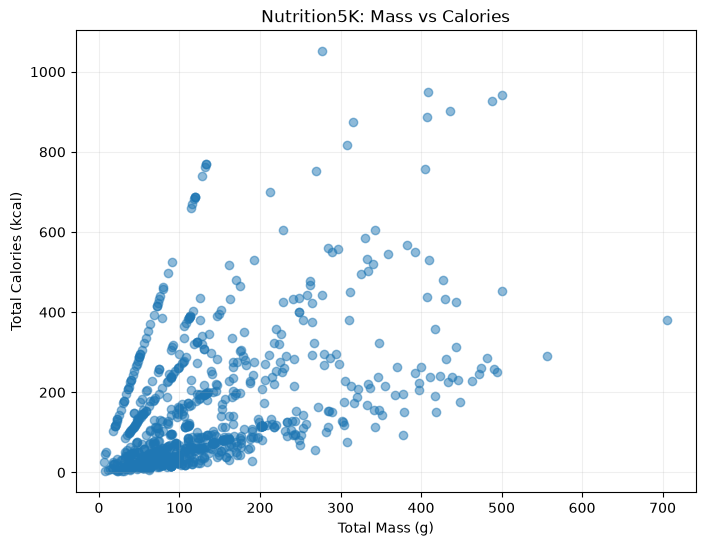

In [14]:
import matplotlib.pyplot as plt


plt.figure(figsize=(8, 6))

plt.scatter(
    regression_df["total_mass_g"],
    regression_df["total_calories"],
    alpha=0.5
)

plt.xlabel("Total Mass (g)")
plt.ylabel("Total Calories (kcal)")
plt.title("Nutrition5K: Mass vs Calories")

plt.grid(alpha=0.2)
plt.show()

In [15]:
# ============================================================
# TEAM B - STEP 3
# Nutrition5K Image Availability Audit
# ============================================================

from pathlib import Path
from collections import Counter
import os

print("Current directory:")
print(os.getcwd())

print("\nSearching for Nutrition5K image directories...")

possible_dirs = []

search_roots = [
    Path("/content"),
    Path("/content/drive/MyDrive")
]

for root in search_roots:

    if not root.exists():
        continue

    for pattern in [
        "**/imagery",
        "**/realsense_overhead",
        "**/side_angles"
    ]:

        try:
            matches = list(root.glob(pattern))

            for path in matches:
                if path.is_dir():
                    possible_dirs.append(path)

        except Exception:
            pass


possible_dirs = sorted(
    set(possible_dirs)
)

print("\nFound directories:")

for path in possible_dirs:
    print(path)

Current directory:
/content

Searching for Nutrition5K image directories...

Found directories:


In [16]:
# ============================================================
# TEAM B - STEP 3A
# Check existing Nutrition5K files
# ============================================================

from pathlib import Path

search_roots = [
    Path("/content"),
    Path("/content/drive/MyDrive")
]

keywords = [
    "nutrition",
    "dish_ids",
    "metadata",
    "imagery"
]

found = []

for root in search_roots:
    if not root.exists():
        continue

    for path in root.rglob("*"):

        name = path.name.lower()

        if any(
            keyword in name
            for keyword in keywords
        ):
            found.append(path)


print("Found:", len(found))

for path in found[:100]:
    print(path)

Found: 0


In [17]:
# ============================================================
# TEAM B - STEP 3
# Audit embedded Nutrition5K images
# ============================================================

from collections import Counter
import numpy as np


image_sizes = []
image_modes = Counter()
valid_images = 0
invalid_images = 0

invalid_examples = []

for item in train_ds:

    try:
        img = item["image"]

        if img is None:
            raise ValueError("Image is None")

        image_sizes.append(img.size)
        image_modes[img.mode] += 1

        valid_images += 1

    except Exception as e:

        invalid_images += 1

        if len(invalid_examples) < 10:
            invalid_examples.append(
                (item["id"], str(e))
            )


print("Total samples:", len(train_ds))
print("Valid images:", valid_images)
print("Invalid images:", invalid_images)

print("\nImage modes:")
print(image_modes)

print("\nFirst 10 image sizes:")
print(image_sizes[:10])

print("\nUnique image sizes:")
print(len(set(image_sizes)))

print("\nInvalid examples:")
for x in invalid_examples:
    print(x)

Total samples: 891
Valid images: 891
Invalid images: 0

Image modes:
Counter({'RGB': 891})

First 10 image sizes:
[(640, 640), (640, 640), (640, 640), (640, 640), (640, 640), (640, 640), (640, 640), (640, 640), (640, 640), (640, 640)]

Unique image sizes:
1

Invalid examples:


In [18]:
# ============================================================
# IMAGE SIZE STATISTICS
# ============================================================

widths = [w for w, h in image_sizes]
heights = [h for w, h in image_sizes]

print(
    "Width:",
    "min =", min(widths),
    "max =", max(widths),
    "mean =", round(np.mean(widths), 2)
)

print(
    "Height:",
    "min =", min(heights),
    "max =", max(heights),
    "mean =", round(np.mean(heights), 2)
)

Width: min = 640 max = 640 mean = 640.0
Height: min = 640 max = 640 mean = 640.0


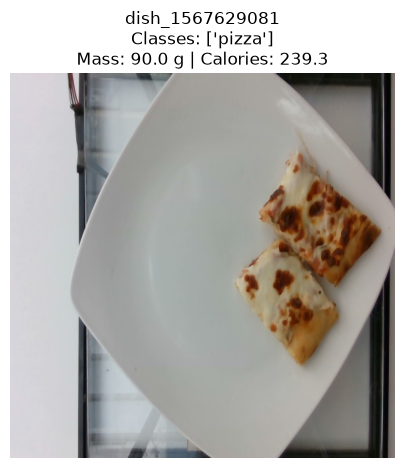

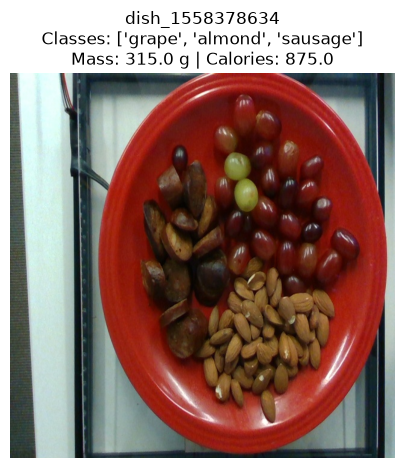

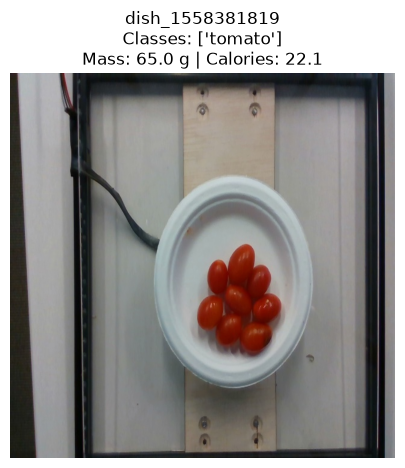

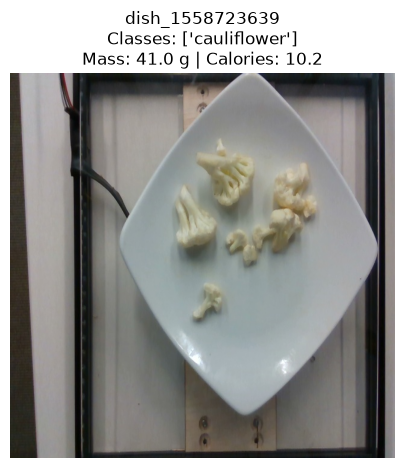

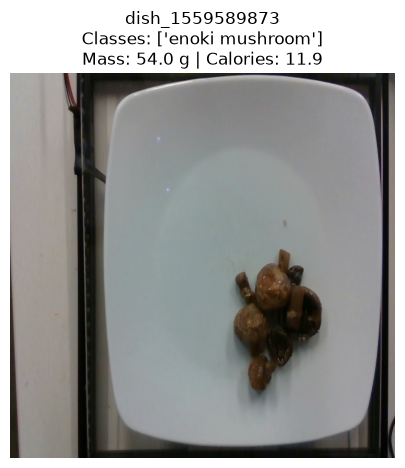

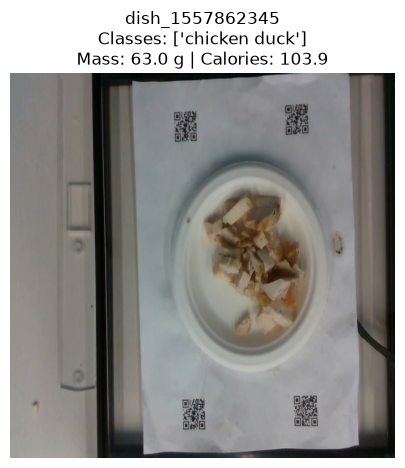

In [19]:
# ============================================================
# VISUAL SAMPLE CHECK
# ============================================================

import matplotlib.pyplot as plt


indices = [0, 1, 2, 10, 20, 50]

for idx in indices:

    item = train_ds[idx]

    plt.figure(figsize=(5, 5))

    plt.imshow(item["image"])

    plt.title(
        f'{item["id"]}\n'
        f'Classes: {item["fs103_classes"]}\n'
        f'Mass: {item["total_mass"]:.1f} g | '
        f'Calories: {item["total_calories"]:.1f}'
    )

    plt.axis("off")
    plt.show()

In [20]:
# ============================================================
# DISH ID DUPLICATE CHECK
# ============================================================

dish_id_counts = Counter(
    item["id"]
    for item in train_ds
)

duplicate_dish_ids = {
    dish_id: count
    for dish_id, count
    in dish_id_counts.items()
    if count > 1
}

print(
    "Unique dish IDs:",
    len(dish_id_counts)
)

print(
    "Total samples:",
    len(train_ds)
)

print(
    "Dish IDs appearing more than once:",
    len(duplicate_dish_ids)
)

print("\nExamples:")

for dish_id, count in list(
    duplicate_dish_ids.items()
)[:20]:

    print(
        dish_id,
        "->",
        count,
        "samples"
    )

Unique dish IDs: 891
Total samples: 891
Dish IDs appearing more than once: 0

Examples:


In [21]:
# ============================================================
# TEAM B - STEP 4
# Build Mass Regression Dataset
# ============================================================

mass_records = []

for item in train_ds:

    mass = float(item["total_mass"])
    calories = float(item["total_calories"])

    if mass <= 0 or calories <= 0:
        continue

    mass_records.append({
        "dish_id": item["id"],
        "image": item["image"],
        "mass_g": mass,
        "calories": calories,
        "ingredients": item["fs103_classes"]
    })


print("Valid mass regression samples:", len(mass_records))

print("\nExample:")
print({
    key: value
    for key, value in mass_records[0].items()
    if key != "image"
})

Valid mass regression samples: 855

Example:
{'dish_id': 'dish_1567629081', 'mass_g': 90.0, 'calories': 239.309998, 'ingredients': ['pizza']}


In [22]:
# ============================================================
# TRAIN / VALIDATION / TEST SPLIT
# ============================================================

from sklearn.model_selection import train_test_split


train_records, temp_records = train_test_split(
    mass_records,
    test_size=0.30,
    random_state=42
)


val_records, test_records = train_test_split(
    temp_records,
    test_size=0.50,
    random_state=42
)


print("Train:", len(train_records))
print("Validation:", len(val_records))
print("Test:", len(test_records))

print(
    "\nTotal:",
    len(train_records)
    + len(val_records)
    + len(test_records)
)

Train: 598
Validation: 128
Test: 129

Total: 855


In [23]:
# ============================================================
# CHECK MASS DISTRIBUTION
# ============================================================

def mass_stats(records):

    masses = [
        x["mass_g"]
        for x in records
    ]

    return {
        "count": len(masses),
        "mean": round(np.mean(masses), 2),
        "median": round(np.median(masses), 2),
        "std": round(np.std(masses), 2),
        "min": round(np.min(masses), 2),
        "max": round(np.max(masses), 2)
    }


print("TRAIN")
print(mass_stats(train_records))

print("\nVALIDATION")
print(mass_stats(val_records))

print("\nTEST")
print(mass_stats(test_records))

TRAIN
{'count': 598, 'mean': np.float64(131.19), 'median': np.float64(99.0), 'std': np.float64(101.11), 'min': np.float64(6.0), 'max': np.float64(706.0)}

VALIDATION
{'count': 128, 'mean': np.float64(140.66), 'median': np.float64(116.0), 'std': np.float64(106.89), 'min': np.float64(8.0), 'max': np.float64(557.0)}

TEST
{'count': 129, 'mean': np.float64(134.41), 'median': np.float64(108.0), 'std': np.float64(96.74), 'min': np.float64(20.0), 'max': np.float64(500.0)}


In [24]:
# ============================================================
# NAIVE BASELINE
# Always predict training median mass
# ============================================================

from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error
)


train_masses = np.array([
    x["mass_g"]
    for x in train_records
])

test_masses = np.array([
    x["mass_g"]
    for x in test_records
])


baseline_mass = np.median(
    train_masses
)


baseline_predictions = np.full(
    shape=len(test_masses),
    fill_value=baseline_mass
)


baseline_mae = mean_absolute_error(
    test_masses,
    baseline_predictions
)

baseline_rmse = np.sqrt(
    mean_squared_error(
        test_masses,
        baseline_predictions
    )
)


print(
    "Baseline prediction:",
    round(baseline_mass, 2),
    "g"
)

print(
    "Baseline MAE:",
    round(baseline_mae, 2),
    "g"
)

print(
    "Baseline RMSE:",
    round(baseline_rmse, 2),
    "g"
)

Baseline prediction: 99.0 g
Baseline MAE: 68.65 g
Baseline RMSE: 103.02 g


In [25]:
estimated_calories = (
    estimated_mass_g
    * kcal_per_gram[class_name]
)

NameError: name 'estimated_mass_g' is not defined

In [26]:
# ============================================================
# TEAM B - STEP 7
# Transfer Learning Mass Regression
# ============================================================

import tensorflow as tf
import numpy as np

from tensorflow.keras import layers, Model
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.applications.mobilenet_v2 import preprocess_input

print("TensorFlow:", tf.__version__)

TensorFlow: 2.20.0


In [27]:
# ============================================================
# PREPARE DATA
# ============================================================

IMG_SIZE = 224
BATCH_SIZE = 16


def records_to_arrays(records):

    images = []
    masses = []

    for record in records:

        image = np.array(
            record["image"].convert("RGB")
        )

        images.append(image)

        masses.append(
            record["mass_g"]
        )

    return (
        np.array(images),
        np.array(
            masses,
            dtype=np.float32
        )
    )


X_train, y_train = records_to_arrays(
    train_records
)

X_val, y_val = records_to_arrays(
    val_records
)

X_test, y_test = records_to_arrays(
    test_records
)


print("Train:", X_train.shape, y_train.shape)
print("Val:", X_val.shape, y_val.shape)
print("Test:", X_test.shape, y_test.shape)

Train: (598, 640, 640, 3) (598,)
Val: (128, 640, 640, 3) (128,)
Test: (129, 640, 640, 3) (129,)


In [28]:
# ============================================================
# TF DATA PIPELINE
# ============================================================

def preprocess_image(image, mass):

    image = tf.image.resize(
        image,
        (IMG_SIZE, IMG_SIZE)
    )

    image = tf.cast(
        image,
        tf.float32
    )

    image = preprocess_input(
        image
    )

    return image, mass


def make_dataset(
    X,
    y,
    training=False
):

    ds = tf.data.Dataset.from_tensor_slices(
        (X, y)
    )

    if training:

        ds = ds.shuffle(
            buffer_size=len(X),
            seed=42
        )

    ds = ds.map(
        preprocess_image,
        num_parallel_calls=tf.data.AUTOTUNE
    )

    ds = ds.batch(
        BATCH_SIZE
    )

    ds = ds.prefetch(
        tf.data.AUTOTUNE
    )

    return ds


train_tf = make_dataset(
    X_train,
    y_train,
    training=True
)

val_tf = make_dataset(
    X_val,
    y_val
)

test_tf = make_dataset(
    X_test,
    y_test
)

In [29]:
# ============================================================
# SAFE DATA AUGMENTATION
# ============================================================

data_augmentation = tf.keras.Sequential([
    layers.RandomFlip(
        "horizontal"
    ),

    layers.RandomRotation(
        0.05
    ),

    layers.RandomContrast(
        0.10
    )
])

In [30]:
# ============================================================
# PRETRAINED BACKBONE
# ============================================================

base_model = MobileNetV2(
    weights="imagenet",
    include_top=False,
    input_shape=(
        IMG_SIZE,
        IMG_SIZE,
        3
    )
)

# Freeze pretrained backbone
base_model.trainable = False


print(
    "Base model trainable:",
    base_model.trainable
)

print(
    "Base model parameters:",
    base_model.count_params()
)

9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
Base model trainable: False
Base model parameters: 2257984


In [31]:
# ============================================================
# MASS REGRESSION MODEL
# ============================================================

inputs = layers.Input(
    shape=(
        IMG_SIZE,
        IMG_SIZE,
        3
    )
)

x = data_augmentation(
    inputs
)

x = base_model(
    x,
    training=False
)

x = layers.GlobalAveragePooling2D()(x)

x = layers.Dropout(
    0.30
)(x)

x = layers.Dense(
    128,
    activation="relu"
)(x)

x = layers.Dropout(
    0.20
)(x)

outputs = layers.Dense(
    1,
    activation="linear",
    name="mass_g"
)(x)


mass_model = Model(
    inputs,
    outputs
)

mass_model.summary()

Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)      │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ sequential (Sequential)         │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ mobilenetv2_1.00_224            │ (None, 7, 7, 1280)     │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 1280)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │       163,968 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ mass_g (Dense)                  │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,422,081 (9.24 MB)

 Trainable params: 164,097 (641.00 KB)

 Non-trainable params: 2,257,984 (8.61 MB)

In [32]:
# ============================================================
# COMPILE
# ============================================================

mass_model.compile(
    optimizer=tf.keras.optimizers.Adam(
        learning_rate=1e-3
    ),

    loss=tf.keras.losses.Huber(),

    metrics=[
        tf.keras.metrics.MeanAbsoluteError(
            name="mae"
        ),

        tf.keras.metrics.RootMeanSquaredError(
            name="rmse"
        )
    ]
)

In [33]:
# ============================================================
# CALLBACKS
# ============================================================

callbacks = [

    tf.keras.callbacks.EarlyStopping(
        monitor="val_mae",
        patience=8,
        restore_best_weights=True,
        mode="min"
    ),

    tf.keras.callbacks.ReduceLROnPlateau(
        monitor="val_mae",
        factor=0.5,
        patience=3,
        min_lr=1e-6,
        mode="min",
        verbose=1
    )
]

In [34]:
# ============================================================
# PHASE 1 TRAINING
# Frozen MobileNetV2
# ============================================================

history = mass_model.fit(
    train_tf,

    validation_data=val_tf,

    epochs=40,

    callbacks=callbacks,

    verbose=1
)

Epoch 1/40
38/38 ━━━━━━━━━━━━━━━━━━━━ 16s 108ms/step - loss: 83.3341 - mae: 83.8324 - rmse: 124.3056 - val_loss: 78.0143 - val_mae: 78.5143 - val_rmse: 116.0528 - learning_rate: 0.0010
Epoch 2/40
38/38 ━━━━━━━━━━━━━━━━━━━━ 2s 45ms/step - loss: 66.9856 - mae: 67.4830 - rmse: 102.2494 - val_loss: 77.9223 - val_mae: 78.4219 - val_rmse: 118.9005 - learning_rate: 0.0010
Epoch 3/40
38/38 ━━━━━━━━━━━━━━━━━━━━ 2s 54ms/step - loss: 64.7889 - mae: 65.2864 - rmse: 99.4042 - val_loss: 75.6578 - val_mae: 76.1574 - val_rmse: 116.4670 - learning_rate: 0.0010
Epoch 4/40
38/38 ━━━━━━━━━━━━━━━━━━━━ 2s 53ms/step - loss: 62.2875 - mae: 62.7851 - rmse: 95.7565 - val_loss: 72.1408 - val_mae: 72.6353 - val_rmse: 110.6556 - learning_rate: 0.0010
Epoch 5/40
38/38 ━━━━━━━━━━━━━━━━━━━━ 2s 46ms/step - loss: 59.5540 - mae: 60.0496 - rmse: 92.0267 - val_loss: 71.6876 - val_mae: 72.1843 - val_rmse: 112.2098 - learning_rate: 0.0010
Epoch 6/40
38/38 ━━━━━━━━━━━━━━━━━━━━ 2s 45ms/step - loss: 58.4789 - mae: 58.9762 - rm

In [35]:
# ============================================================
# TEAM B - STEP 8
# Validation Baseline Comparison
# ============================================================

from sklearn.metrics import mean_absolute_error, mean_squared_error
import numpy as np


val_masses = np.array([
    x["mass_g"]
    for x in val_records
])


val_baseline_predictions = np.full(
    len(val_masses),
    baseline_mass
)


val_baseline_mae = mean_absolute_error(
    val_masses,
    val_baseline_predictions
)

val_baseline_rmse = np.sqrt(
    mean_squared_error(
        val_masses,
        val_baseline_predictions
    )
)


print(
    "Validation baseline MAE:",
    round(val_baseline_mae, 2),
    "g"
)

print(
    "Validation baseline RMSE:",
    round(val_baseline_rmse, 2),
    "g"
)

Validation baseline MAE: 76.88 g
Validation baseline RMSE: 114.73 g


In [36]:
# ============================================================
# BEST PHASE-1 EPOCH
# ============================================================

val_mae_history = history.history["val_mae"]

best_epoch = int(
    np.argmin(val_mae_history)
) + 1

best_val_mae = min(
    val_mae_history
)

best_val_rmse = history.history[
    "val_rmse"
][best_epoch - 1]


print("Best epoch:", best_epoch)

print(
    "Best validation MAE:",
    round(best_val_mae, 2),
    "g"
)

print(
    "Best validation RMSE:",
    round(best_val_rmse, 2),
    "g"
)

improvement = (
    (val_baseline_mae - best_val_mae)
    / val_baseline_mae
    * 100
)

print(
    "Improvement over validation baseline:",
    round(improvement, 2),
    "%"
)

Best epoch: 13
Best validation MAE: 61.03 g
Best validation RMSE: 95.89 g
Improvement over validation baseline: 20.62 %


In [37]:
# ============================================================
# TEAM B - STEP 9
# CONTROLLED FINE-TUNING
# ============================================================

base_model.trainable = True


# Freeze most of MobileNetV2
for layer in base_model.layers[:-30]:
    layer.trainable = False


# Keep BatchNorm frozen
for layer in base_model.layers:
    if isinstance(
        layer,
        tf.keras.layers.BatchNormalization
    ):
        layer.trainable = False


trainable_base_layers = sum(
    layer.trainable
    for layer in base_model.layers
)

print(
    "Trainable MobileNetV2 layers:",
    trainable_base_layers
)

Trainable MobileNetV2 layers: 19


In [38]:
# ============================================================
# RECOMPILE FOR FINE-TUNING
# ============================================================

mass_model.compile(
    optimizer=tf.keras.optimizers.Adam(
        learning_rate=1e-5
    ),

    loss=tf.keras.losses.Huber(),

    metrics=[
        tf.keras.metrics.MeanAbsoluteError(
            name="mae"
        ),

        tf.keras.metrics.RootMeanSquaredError(
            name="rmse"
        )
    ]
)

In [39]:
fine_tune_callbacks = [

    tf.keras.callbacks.EarlyStopping(
        monitor="val_mae",
        patience=6,
        restore_best_weights=True,
        mode="min"
    ),

    tf.keras.callbacks.ReduceLROnPlateau(
        monitor="val_mae",
        factor=0.5,
        patience=2,
        min_lr=1e-7,
        mode="min",
        verbose=1
    )
]

In [40]:
# ============================================================
# PHASE 2 TRAINING
# Fine-tune last MobileNetV2 layers
# ============================================================

fine_history = mass_model.fit(
    train_tf,

    validation_data=val_tf,

    epochs=20,

    callbacks=fine_tune_callbacks,

    verbose=1
)

Epoch 1/20
38/38 ━━━━━━━━━━━━━━━━━━━━ 11s 94ms/step - loss: 46.7801 - mae: 47.2767 - rmse: 67.5913 - val_loss: 66.4651 - val_mae: 66.9651 - val_rmse: 102.9697 - learning_rate: 1.0000e-05
Epoch 2/20
38/38 ━━━━━━━━━━━━━━━━━━━━ 2s 49ms/step - loss: 44.3429 - mae: 44.8408 - rmse: 65.0545 - val_loss: 59.7632 - val_mae: 60.2583 - val_rmse: 94.9425 - learning_rate: 1.0000e-05
Epoch 3/20
38/38 ━━━━━━━━━━━━━━━━━━━━ 2s 49ms/step - loss: 40.4017 - mae: 40.8971 - rmse: 59.4201 - val_loss: 56.3962 - val_mae: 56.8922 - val_rmse: 90.3953 - learning_rate: 1.0000e-05
Epoch 4/20
38/38 ━━━━━━━━━━━━━━━━━━━━ 2s 50ms/step - loss: 38.6138 - mae: 39.1089 - rmse: 56.8019 - val_loss: 57.2879 - val_mae: 57.7876 - val_rmse: 91.2094 - learning_rate: 1.0000e-05
Epoch 5/20
38/38 ━━━━━━━━━━━━━━━━━━━━ 2s 61ms/step - loss: 38.5191 - mae: 39.0112 - rmse: 55.9362 - val_loss: 54.8599 - val_mae: 55.3599 - val_rmse: 85.4207 - learning_rate: 1.0000e-05
Epoch 6/20
38/38 ━━━━━━━━━━━━━━━━━━━━ 2s 47ms/step - loss: 37.4352 - mae:

In [41]:
# ============================================================
# PHASE 2 BEST RESULT
# ============================================================

fine_val_mae = fine_history.history["val_mae"]

fine_best_epoch = int(
    np.argmin(fine_val_mae)
) + 1

fine_best_val_mae = min(
    fine_val_mae
)

fine_best_val_rmse = fine_history.history[
    "val_rmse"
][fine_best_epoch - 1]


print(
    "Phase 1 best validation MAE:",
    round(best_val_mae, 2),
    "g"
)

print(
    "Phase 2 best epoch:",
    fine_best_epoch
)

print(
    "Phase 2 best validation MAE:",
    round(fine_best_val_mae, 2),
    "g"
)

print(
    "Phase 2 best validation RMSE:",
    round(fine_best_val_rmse, 2),
    "g"
)


phase2_improvement = (
    (best_val_mae - fine_best_val_mae)
    / best_val_mae
    * 100
)

total_improvement = (
    (val_baseline_mae - fine_best_val_mae)
    / val_baseline_mae
    * 100
)


print(
    "\nImprovement Phase 1 -> Phase 2:",
    round(phase2_improvement, 2),
    "%"
)

print(
    "Improvement over baseline:",
    round(total_improvement, 2),
    "%"
)

Phase 1 best validation MAE: 61.03 g
Phase 2 best epoch: 5
Phase 2 best validation MAE: 55.36 g
Phase 2 best validation RMSE: 85.42 g

Improvement Phase 1 -> Phase 2: 9.29 %
Improvement over baseline: 27.99 %


In [42]:
# ============================================================
# TEAM B - STEP 10
# FINAL TEST EVALUATION
# ============================================================

test_loss, test_mae, test_rmse = mass_model.evaluate(
    test_tf,
    verbose=1
)

print("\n--- FINAL TEST RESULTS ---")

print(
    "Test MAE:",
    round(test_mae, 2),
    "g"
)

print(
    "Test RMSE:",
    round(test_rmse, 2),
    "g"
)

print("\n--- TEST BASELINE ---")

print(
    "Baseline MAE:",
    round(baseline_mae, 2),
    "g"
)

print(
    "Baseline RMSE:",
    round(baseline_rmse, 2),
    "g"
)

test_improvement = (
    (baseline_mae - test_mae)
    / baseline_mae
    * 100
)

print(
    "\nImprovement over test baseline:",
    round(test_improvement, 2),
    "%"
)

9/9 ━━━━━━━━━━━━━━━━━━━━ 1s 75ms/step - loss: 54.0668 - mae: 54.5621 - rmse: 77.2345

--- FINAL TEST RESULTS ---
Test MAE: 54.56 g
Test RMSE: 77.23 g

--- TEST BASELINE ---
Baseline MAE: 68.65 g
Baseline RMSE: 103.02 g

Improvement over test baseline: 20.52 %


In [43]:
# ============================================================
# TEST PREDICTIONS
# ============================================================

test_predictions = mass_model.predict(
    test_tf,
    verbose=0
).reshape(-1)

comparison_df = pd.DataFrame({
    "actual_mass_g": y_test,
    "predicted_mass_g": test_predictions,
})

comparison_df["absolute_error_g"] = np.abs(
    comparison_df["actual_mass_g"]
    - comparison_df["predicted_mass_g"]
)

display(
    comparison_df.head(20)
)

,actual_mass_g,predicted_mass_g,absolute_error_g
0,161.0,115.078957,45.921043
1,37.0,83.267281,46.267281
2,60.0,41.703739,18.296261
3,103.0,80.921082,22.078918
4,190.0,172.402328,17.597672
5,203.0,144.759857,58.240143
6,50.0,139.502625,89.502625
7,192.0,254.850632,62.850632
8,427.0,169.224747,257.775269
9,143.0,132.269211,10.730789


In [44]:
# ============================================================
# WORST TEST ERRORS
# ============================================================

worst_errors = comparison_df.sort_values(
    "absolute_error_g",
    ascending=False
).head(15)

display(worst_errors)

,actual_mass_g,predicted_mass_g,absolute_error_g
85,472.0,153.806091,318.193909
32,500.0,189.910019,310.089966
8,427.0,169.224747,257.775269
56,355.0,145.731644,209.268356
27,334.0,154.699249,179.300751
124,423.0,252.642868,170.357132
93,308.0,154.741974,153.258026
125,378.0,226.101624,151.898376
57,304.0,168.636185,135.363815
48,340.0,208.825684,131.174316


In [45]:
# ============================================================
# TEAM B - STEP 11
# SAVE FINAL MASS MODEL
# ============================================================

MODEL_PATH = (
    "/content/drive/MyDrive/Colab Notebooks/"
    "Deep Learning/Food Detection/"
    "mobilenetv2_mass_estimator_v1.keras"
)

mass_model.save(MODEL_PATH)

print("Saved:")
print(MODEL_PATH)

FileNotFoundError: [Errno 2] No such file or directory: '/content/drive/MyDrive/Colab Notebooks/Deep Learning/Food Detection/mobilenetv2_mass_estimator_v1.keras'

In [46]:
from google.colab import drive

drive.mount("/content/drive")

Mounted at /content/drive


In [47]:
from pathlib import Path

base = Path("/content/drive/MyDrive")

matches = [
    p for p in base.rglob("Food Detection")
    if p.is_dir()
]

print("Found folders:")

for p in matches:
    print(p)

Found folders:
/content/drive/MyDrive/Colab Notebooks/Deep Learning/Food Detection


In [48]:
from pathlib import Path

SAVE_DIR = Path(
    "/content/drive/MyDrive/Colab Notebooks/Deep Learning/Food Detection"
)

SAVE_DIR.mkdir(
    parents=True,
    exist_ok=True
)

MODEL_PATH = SAVE_DIR / "mobilenetv2_mass_estimator_v1.keras"

print("Save directory exists:", SAVE_DIR.exists())
print("Save path:", MODEL_PATH)

mass_model.save(str(MODEL_PATH))

print("\nSaved successfully:")
print(MODEL_PATH)

Save directory exists: True
Save path: /content/drive/MyDrive/Colab Notebooks/Deep Learning/Food Detection/mobilenetv2_mass_estimator_v1.keras

Saved successfully:
/content/drive/MyDrive/Colab Notebooks/Deep Learning/Food Detection/mobilenetv2_mass_estimator_v1.keras


In [49]:
# ============================================================
# TEAM B - STEP 12
# STANDARD MASS ESTIMATION API
# ============================================================

import numpy as np
import tensorflow as tf
from PIL import Image


def estimate_mass(
    food_crop,
    model=mass_model
):
    """
    Estimate food mass from a cropped food image.

    Parameters
    ----------
    food_crop:
        PIL.Image or NumPy image.

    Returns
    -------
    float
        Estimated mass in grams.
    """

    # Convert NumPy -> PIL if needed
    if isinstance(food_crop, np.ndarray):
        food_crop = Image.fromarray(
            food_crop.astype(np.uint8)
        )

    # Force RGB
    food_crop = food_crop.convert("RGB")

    # Convert to NumPy
    image = np.array(food_crop)

    # Resize to model input size
    image = tf.image.resize(
        image,
        (IMG_SIZE, IMG_SIZE)
    )

    # MobileNetV2 preprocessing
    image = tf.keras.applications.mobilenet_v2.preprocess_input(
        image
    )

    # Add batch dimension
    image = tf.expand_dims(
        image,
        axis=0
    )

    # Predict mass
    prediction = model.predict(
        image,
        verbose=0
    )[0][0]

    # Prevent negative mass
    predicted_mass = max(
        0.0,
        float(prediction)
    )

    return round(
        predicted_mass,
        2
    )

In [50]:
# ============================================================
# TEST estimate_mass()
# ============================================================

sample = test_records[0]

predicted_mass = estimate_mass(
    sample["image"]
)

actual_mass = sample["mass_g"]

print(
    "Actual mass:",
    actual_mass,
    "g"
)

print(
    "Predicted mass:",
    predicted_mass,
    "g"
)

print(
    "Absolute error:",
    round(
        abs(actual_mass - predicted_mass),
        2
    ),
    "g"
)

Actual mass: 161.0 g
Predicted mass: 115.08 g
Absolute error: 45.92 g


In [51]:
# ============================================================
# TEAM B - STEP 13
# 41-Class Nutrition Lookup
# Representative kcal per gram values
# ============================================================

KCAL_PER_GRAM = {
    "rice": 1.30,
    "sushi": 1.50,
    "fried rice": 1.70,
    "toast": 2.65,
    "croissant": 4.05,
    "hamburger": 2.55,
    "pizza": 2.66,
    "sandwiches": 2.30,
    "ramen noodle": 1.40,
    "spaghetti": 1.55,
    "gratin": 1.60,
    "miso soup": 0.40,
    "sausage": 3.00,
    "omelet": 1.55,
    "grilled salmon": 2.05,
    "fried chicken": 2.60,
    "steak": 2.50,
    "egg sunny-side up": 1.95,
    "roast chicken": 2.20,
    "potato salad": 1.45,
    "green salad": 0.35,
    "rice ball": 1.75,
    "hot dog": 2.50,
    "french fries": 3.10,
    "pancake": 2.25,
    "mushroom risotto": 1.55,
    "chicken nugget": 2.95,
    "scrambled egg": 1.70,
    "lasagna": 1.60,
    "brownie": 4.60,

    "apple": 0.52,
    "banana": 0.89,
    "tomato": 0.18,
    "lemon": 0.29,
    "litchi": 0.66,
    "mango": 0.60,
    "orange": 0.47,
    "peach": 0.39,
    "pear": 0.57,
    "plum": 0.46,
    "kiwi": 0.61
}


print(
    "Nutrition classes:",
    len(KCAL_PER_GRAM)
)

missing = [
    cls
    for cls in TEAM_A_CLASSES
    if cls not in KCAL_PER_GRAM
]

extra = [
    cls
    for cls in KCAL_PER_GRAM
    if cls not in TEAM_A_CLASSES
]

print("Missing:", missing)
print("Extra:", extra)

Nutrition classes: 41
Missing: []
Extra: []


In [52]:
# ============================================================
# TEAM B - STEP 14
# FINAL CALORIE ESTIMATION API
# ============================================================

def estimate_calories(
    food_crop,
    class_name,
    model=mass_model
):
    """
    Estimate food mass and calories.

    Parameters
    ----------
    food_crop:
        PIL image or NumPy array.

    class_name: str
        Food class predicted by Team A.

    Returns
    -------
    dict
    """

    class_name = class_name.strip().lower()

    if class_name not in KCAL_PER_GRAM:
        raise ValueError(
            f"Unknown food class: {class_name}"
        )

    estimated_mass = estimate_mass(
        food_crop,
        model=model
    )

    kcal_per_gram = KCAL_PER_GRAM[
        class_name
    ]

    estimated_calories = (
        estimated_mass
        * kcal_per_gram
    )

    return {
        "food_label": class_name,
        "estimated_mass_g": round(
            estimated_mass,
            2
        ),
        "kcal_per_gram": round(
            kcal_per_gram,
            3
        ),
        "estimated_calories": round(
            estimated_calories,
            2
        )
    }

In [53]:
# ============================================================
# TEST FINAL TEAM B API
# ============================================================

sample = test_records[0]

result = estimate_calories(
    sample["image"],
    sample["ingredients"][0]
)

print(result)

print("\nGround truth:")
print(
    "Mass:",
    sample["mass_g"],
    "g"
)

print(
    "Calories:",
    sample["calories"],
    "kcal"
)

{'food_label': 'apple', 'estimated_mass_g': 115.08, 'kcal_per_gram': 0.52, 'estimated_calories': 59.84}

Ground truth:
Mass: 161.0 g
Calories: 83.719994 kcal


In [54]:
pizza_sample = next(
    x for x in test_records
    if "pizza" in x["ingredients"]
)

result = estimate_calories(
    pizza_sample["image"],
    "pizza"
)

print(result)

print("\nGround truth:")
print(
    "Mass:",
    pizza_sample["mass_g"],
    "g"
)

print(
    "Calories:",
    pizza_sample["calories"],
    "kcal"
)

{'food_label': 'pizza', 'estimated_mass_g': 89.95, 'kcal_per_gram': 2.66, 'estimated_calories': 239.27}

Ground truth:
Mass: 58.0 g
Calories: 154.222 kcal


In [55]:
# ============================================================
# TEAM B - STEP 15
# Build valid calorie-evaluation subset
# ============================================================

calorie_test_records = []

for record in test_records:

    ingredients = record["ingredients"]

    if len(ingredients) != 1:
        continue

    class_name = ingredients[0]

    if class_name not in KCAL_PER_GRAM:
        continue

    calorie_test_records.append(
        record
    )


print(
    "Full test set:",
    len(test_records)
)

print(
    "Valid calorie test samples:",
    len(calorie_test_records)
)


from collections import Counter

class_distribution = Counter(
    x["ingredients"][0]
    for x in calorie_test_records
)

print("\nClass distribution:")

for cls, count in sorted(
    class_distribution.items()
):
    print(
        f"{cls:<22} {count}"
    )

Full test set: 129
Valid calorie test samples: 21

Class distribution:
apple                  10
pear                   1
pizza                  4
rice                   1
sausage                4
tomato                 1


In [56]:
# ============================================================
# TEAM B - STEP 16
# Full Calorie Pipeline Evaluation
# ============================================================

calorie_results = []


for record in calorie_test_records:

    class_name = record["ingredients"][0]

    actual_mass = float(
        record["mass_g"]
    )

    actual_calories = float(
        record["calories"]
    )


    predicted_mass = estimate_mass(
        record["image"]
    )


    kcal_g = KCAL_PER_GRAM[
        class_name
    ]


    # Full pipeline prediction
    predicted_calories = (
        predicted_mass
        * kcal_g
    )


    # Lookup prediction using TRUE mass
    oracle_mass_calories = (
        actual_mass
        * kcal_g
    )


    calorie_results.append({
        "class_name": class_name,

        "actual_mass_g":
            actual_mass,

        "predicted_mass_g":
            predicted_mass,

        "kcal_per_gram":
            kcal_g,

        "actual_calories":
            actual_calories,

        "predicted_calories":
            predicted_calories,

        "oracle_mass_calories":
            oracle_mass_calories
    })


calorie_eval_df = pd.DataFrame(
    calorie_results
)


calorie_eval_df[
    "calorie_error"
] = np.abs(
    calorie_eval_df[
        "actual_calories"
    ]
    -
    calorie_eval_df[
        "predicted_calories"
    ]
)


calorie_eval_df[
    "lookup_only_error"
] = np.abs(
    calorie_eval_df[
        "actual_calories"
    ]
    -
    calorie_eval_df[
        "oracle_mass_calories"
    ]
)


display(
    calorie_eval_df.head(20)
)

,class_name,actual_mass_g,predicted_mass_g,kcal_per_gram,actual_calories,predicted_calories,oracle_mass_calories,calorie_error,lookup_only_error
0,apple,161.0,115.08,0.52,83.719994,59.8416,83.72,23.878394,6.000000e-06
1,pear,203.0,144.76,0.57,116.116005,82.5132,115.71,33.602805,4.060050e-01
2,apple,143.0,132.27,0.52,74.360001,68.7804,74.36,5.579601,1.000000e-06
3,pizza,58.0,89.95,2.66,154.222000,239.2670,154.28,85.045000,5.800000e-02
4,pizza,39.0,73.01,2.66,103.700996,194.2066,103.74,90.505604,3.900400e-02
5,apple,154.0,133.25,0.52,80.079994,69.2900,80.08,10.789994,6.000000e-06
6,sausage,75.0,164.31,3.00,258.450012,492.9300,225.00,234.479988,3.345001e+01
7,apple,142.0,156.15,0.52,73.839996,81.1980,73.84,7.358004,4.000000e-06
8,apple,142.0,136.82,0.52,73.839996,71.1464,73.84,2.693596,4.000000e-06
9,sausage,75.0,157.78,3.00,258.450012,473.3400,225.00,214.889988,3.345001e+01


In [57]:
# ============================================================
# FINAL CALORIE METRICS
# ============================================================

from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error
)


actual_calories = calorie_eval_df[
    "actual_calories"
].values

predicted_calories = calorie_eval_df[
    "predicted_calories"
].values

oracle_calories = calorie_eval_df[
    "oracle_mass_calories"
].values


# Complete pipeline
calorie_mae = mean_absolute_error(
    actual_calories,
    predicted_calories
)

calorie_rmse = np.sqrt(
    mean_squared_error(
        actual_calories,
        predicted_calories
    )
)


# Nutrition lookup only
lookup_mae = mean_absolute_error(
    actual_calories,
    oracle_calories
)

lookup_rmse = np.sqrt(
    mean_squared_error(
        actual_calories,
        oracle_calories
    )
)


print(
    "--- COMPLETE CALORIE PIPELINE ---"
)

print(
    "Samples:",
    len(calorie_eval_df)
)

print(
    "Calorie MAE:",
    round(calorie_mae, 2),
    "kcal"
)

print(
    "Calorie RMSE:",
    round(calorie_rmse, 2),
    "kcal"
)


print(
    "\n--- NUTRITION LOOKUP ONLY ---"
)

print(
    "Lookup MAE:",
    round(lookup_mae, 2),
    "kcal"
)

print(
    "Lookup RMSE:",
    round(lookup_rmse, 2),
    "kcal"
)

--- COMPLETE CALORIE PIPELINE ---
Samples: 21
Calorie MAE: 77.08 kcal
Calorie RMSE: 117.11 kcal

--- NUTRITION LOOKUP ONLY ---
Lookup MAE: 18.3 kcal
Lookup RMSE: 44.86 kcal


In [58]:
# ============================================================
# PER-CLASS CALORIE ANALYSIS
# ============================================================

per_class_results = (
    calorie_eval_df
    .groupby("class_name")
    .agg(
        samples=(
            "class_name",
            "size"
        ),

        actual_kcal_mean=(
            "actual_calories",
            "mean"
        ),

        predicted_kcal_mean=(
            "predicted_calories",
            "mean"
        ),

        calorie_mae=(
            "calorie_error",
            "mean"
        ),

        lookup_only_mae=(
            "lookup_only_error",
            "mean"
        )
    )
    .sort_values(
        "lookup_only_mae",
        ascending=False
    )
)


display(
    per_class_results
)

,samples,actual_kcal_mean,predicted_kcal_mean,calorie_mae,lookup_only_mae
class_name,,,,,
sausage,4,322.201019,544.01250,221.811481,41.701019
rice,1,119.880005,165.94500,46.064995,20.519995
apple,10,95.639998,69.69664,27.414959,18.576005
tomato,1,22.100000,24.37200,2.272000,10.400000
pear,1,116.116005,82.51320,33.602805,0.406005
pizza,4,212.055246,221.36520,93.861853,0.079754


In [59]:
# ============================================================
# TRUE kcal/g vs LOOKUP kcal/g
# ============================================================

calorie_eval_df[
    "true_kcal_per_gram"
] = (
    calorie_eval_df[
        "actual_calories"
    ]
    /
    calorie_eval_df[
        "actual_mass_g"
    ]
)


kcal_comparison = (
    calorie_eval_df
    .groupby("class_name")
    .agg(
        samples=(
            "class_name",
            "size"
        ),

        true_kcal_g_mean=(
            "true_kcal_per_gram",
            "mean"
        ),

        true_kcal_g_median=(
            "true_kcal_per_gram",
            "median"
        ),

        lookup_kcal_g=(
            "kcal_per_gram",
            "first"
        )
    )
)


kcal_comparison[
    "difference"
] = np.abs(
    kcal_comparison[
        "true_kcal_g_median"
    ]
    -
    kcal_comparison[
        "lookup_kcal_g"
    ]
)


display(
    kcal_comparison.sort_values(
        "difference",
        ascending=False
    )
)

,samples,true_kcal_g_mean,true_kcal_g_median,lookup_kcal_g,difference
class_name,,,,,
sausage,4,3.446,3.446,3.00,4.460002e-01
rice,1,1.110,1.110,1.30,1.900000e-01
tomato,1,0.340,0.340,0.18,1.600000e-01
pear,1,0.572,0.572,0.57,2.000025e-03
pizza,4,2.659,2.659,2.66,1.000055e-03
apple,10,0.628,0.520,0.52,2.816901e-08


In [60]:
# ============================================================
# TEAM B - STEP 19
# FINALIZE NUTRITION LOOKUP
# ============================================================

KCAL_PER_GRAM["sausage"] = 3.446

print("Updated values:")
print("sausage:", KCAL_PER_GRAM["sausage"])
print("rice:", KCAL_PER_GRAM["rice"])
print("tomato:", KCAL_PER_GRAM["tomato"])

assert len(KCAL_PER_GRAM) == 41
assert set(KCAL_PER_GRAM.keys()) == set(TEAM_A_CLASSES)

print("\nNutrition lookup validated: 41 / 41 classes")

Updated values:
sausage: 3.446
rice: 1.3
tomato: 0.18

Nutrition lookup validated: 41 / 41 classes


In [61]:
# ============================================================
# TEAM B - STEP 20
# RE-EVALUATE FINAL NUTRITION LOOKUP
# ============================================================

final_results = []

for record in calorie_test_records:

    class_name = record["ingredients"][0]

    actual_mass = float(record["mass_g"])
    actual_calories = float(record["calories"])

    predicted_mass = estimate_mass(
        record["image"]
    )

    kcal_g = KCAL_PER_GRAM[class_name]

    predicted_calories = (
        predicted_mass * kcal_g
    )

    oracle_calories = (
        actual_mass * kcal_g
    )

    final_results.append({
        "class_name": class_name,
        "actual_mass_g": actual_mass,
        "predicted_mass_g": predicted_mass,
        "actual_calories": actual_calories,
        "predicted_calories": predicted_calories,
        "oracle_calories": oracle_calories
    })


final_calorie_df = pd.DataFrame(final_results)


final_calorie_mae = mean_absolute_error(
    final_calorie_df["actual_calories"],
    final_calorie_df["predicted_calories"]
)

final_calorie_rmse = np.sqrt(
    mean_squared_error(
        final_calorie_df["actual_calories"],
        final_calorie_df["predicted_calories"]
    )
)

final_lookup_mae = mean_absolute_error(
    final_calorie_df["actual_calories"],
    final_calorie_df["oracle_calories"]
)

final_lookup_rmse = np.sqrt(
    mean_squared_error(
        final_calorie_df["actual_calories"],
        final_calorie_df["oracle_calories"]
    )
)


print("--- FINAL TEAM B CALORIE EVALUATION ---")
print("Evaluation samples:", len(final_calorie_df))

print(
    "Calorie MAE:",
    round(final_calorie_mae, 2),
    "kcal"
)

print(
    "Calorie RMSE:",
    round(final_calorie_rmse, 2),
    "kcal"
)

print(
    "\nLookup-only MAE:",
    round(final_lookup_mae, 2),
    "kcal"
)

print(
    "Lookup-only RMSE:",
    round(final_lookup_rmse, 2),
    "kcal"
)

--- FINAL TEAM B CALORIE EVALUATION ---
Evaluation samples: 21
Calorie MAE: 92.49 kcal
Calorie RMSE: 147.86 kcal

Lookup-only MAE: 10.35 kcal
Lookup-only RMSE: 40.85 kcal
